In [47]:
# Q1
import pandas as pd
import numpy as np

url = "warehouse_messy_data.csv"
df = pd.read_csv(url)

print("First 10 rows:\n", df.head(10))
print("\nShape:", df.shape)
print("\nColumns:", df.columns)
print("\nData Types:\n", df.dtypes)

First 10 rows:
    Product ID Product Name     Category    Warehouse Location     Quantity  \
0        1102    gadget y   ELECTRONICS  Warehouse 2  Aisle 1          300   
1        1435    gadget y   ELECTRONICS  Warehouse 2  Aisle 4  two hundred   
2        1860    widget a      CLOTHING  Warehouse 2  Aisle 3          100   
3        1270    gadget z          TOYS  Warehouse 2  Aisle 4           50   
4        1106    widget a     FURNITURE  Warehouse 3  Aisle 3  two hundred   
5        1071    widget b      CLOTHING  Warehouse 3  Aisle 5          300   
6        1700    widget a      CLOTHING  Warehouse 2  Aisle 2  two hundred   
7        1020    widget c      CLOTHING  Warehouse 1  Aisle 5  two hundred   
8        1614    gadget y   ELECTRONICS  Warehouse 3  Aisle 3          300   
9        1121    widget b          TOYS  Warehouse 1  Aisle 2           50   

   Price    Supplier        Status Last Restocked  
0   9.99  Supplier C      In Stock            NaN  
1  19.99  Supplier C 

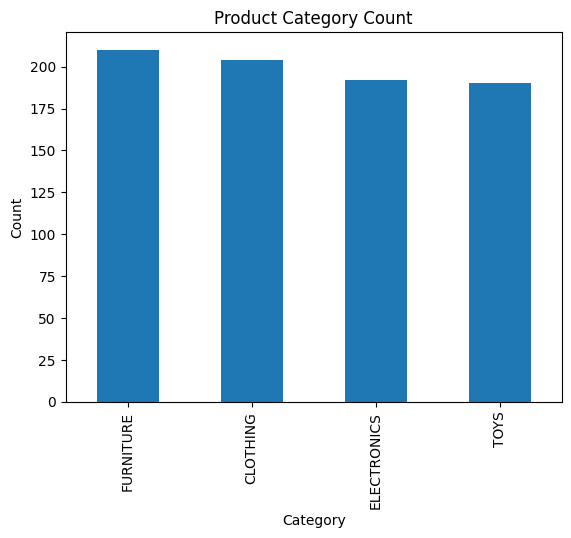

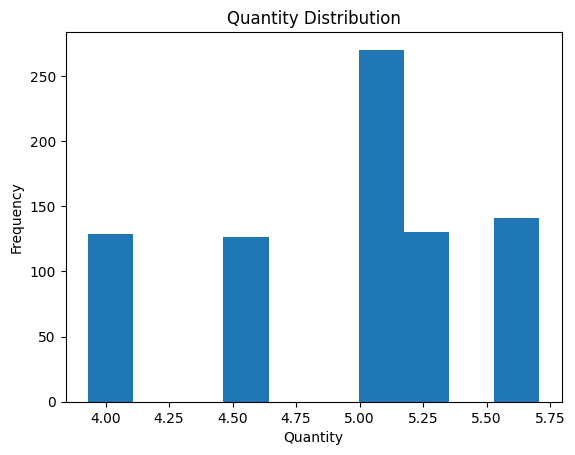

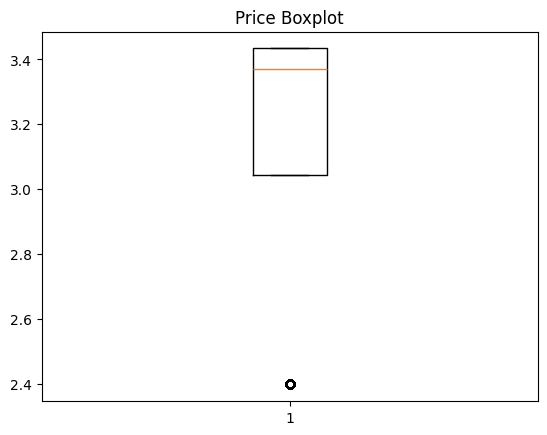

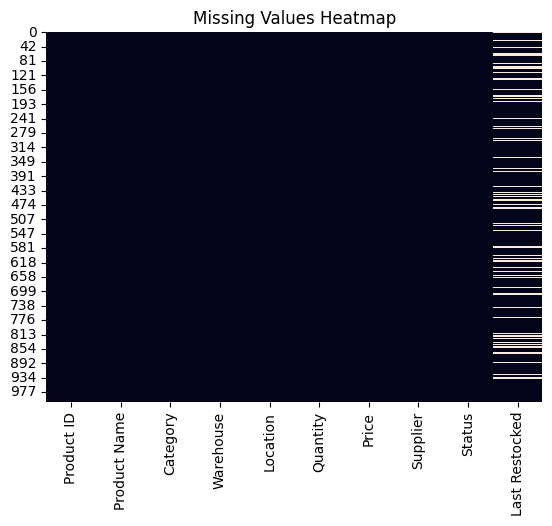

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Load dataset
# ==============================
url = "warehouse_messy_data.csv"
df = pd.read_csv(url)

# ==============================
# Basic cleaning (needed for Q2)
# ==============================

# Remove spaces
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object', 'string']):
    df[col] = df[col].str.strip()
# ==============================
# Handle Missing Values (needed before plotting)
# ==============================

df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Price'] = df['Price'].fillna(df['Price'].mean())

# ==============================
# Handle Outliers (IQR method)
# ==============================

def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

df = remove_outliers(df, 'Quantity')
df = remove_outliers(df, 'Price')

# ==============================
# Handle Skewness (Log transform)
# ==============================

df['Quantity'] = np.log1p(df['Quantity'])
df['Price'] = np.log1p(df['Price'])

# ==============================
# 📊 PLOTS
# ==============================

# 1. Bar chart (Category)
plt.figure()
df['Category'].value_counts().plot(kind='bar')
plt.title("Product Category Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# 2. Histogram (Quantity)
plt.figure()
plt.hist(df['Quantity'])
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# 3. Boxplot (Price)
plt.figure()
plt.boxplot(df['Price'])
plt.title("Price Boxplot")
plt.show()

# ==============================
# Heatmap of Missing Values
# ==============================

plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [38]:
# Q3
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include=['object', 'string']):
    df[col] = df[col].astype(str).str.strip()

df.head()

,Product ID,Product Name,Category,Warehouse,Location,Quantity,Price,Supplier,Status,Last Restocked
1,1435,Gadget Y,ELECTRONICS,Warehouse 2,Aisle 4,0.714998,0.628246,Supplier C,Out of Stock,20/12/2022
2,1860,Widget A,CLOTHING,Warehouse 2,Aisle 3,0.694465,0.628246,Supplier B,In Stock,20/12/2022
3,1270,Gadget Z,TOYS,Warehouse 2,Aisle 4,0.669807,0.663110,Supplier B,In Stock,20/12/2022
5,1071,Widget B,CLOTHING,Warehouse 3,Aisle 5,0.725519,0.638026,Supplier A,In Stock,20/12/2022
6,1700,Widget A,CLOTHING,Warehouse 2,Aisle 2,0.714998,0.663110,Supplier B,In Stock,20/12/2022


In [32]:
# Q4
if 'Product Name' in df.columns:
    df['Product Name'] = df['Product Name'].str.title()

df.head()

,Product ID,Product Name,Category,Warehouse,Location,Quantity,Price,Supplier,Status,Last Restocked
0,1102,Gadget Y,ELECTRONICS,Warehouse 2,Aisle 1,1.903168,1.241158,Supplier C,In Stock,20/12/2022
1,1435,Gadget Y,ELECTRONICS,Warehouse 2,Aisle 4,1.841074,1.397246,Supplier C,Out of Stock,20/12/2022
2,1860,Widget A,CLOTHING,Warehouse 2,Aisle 3,1.725463,1.397246,Supplier B,In Stock,20/12/2022
3,1270,Gadget Z,TOYS,Warehouse 2,Aisle 4,1.595709,1.595669,Supplier B,In Stock,20/12/2022
4,1106,Widget A,FURNITURE,Warehouse 3,Aisle 3,1.841074,1.241158,Supplier D,Out of Stock,25/04/2023


In [40]:
# Q5
duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

df.drop_duplicates(inplace=True)

Duplicate records: 0


In [44]:
# Q6
import numpy as np

# Replace "NaN" string with actual NaN
df = df.replace("NaN", np.nan)

for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

Product ID        0
Product Name      0
Category          0
Warehouse         0
Location          0
Quantity          0
Price             0
Supplier          0
Status            0
Last Restocked    0
dtype: int64

In [3]:
from word2number import w2n 
def convert_words(x):
    try:
        return w2n.word_to_num(x)
    except:
        return x
df['Quantity']=df['Quantity'].apply(convert_words)
df['Price']=df['Price'].apply(convert_words)

df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')
df['Price']=pd.to_numeric(df['Price'],errors='coerce')
df.head()

,Product ID,Product Name,Category,Warehouse,Location,Quantity,Price,Supplier,Status,Last Restocked
0,1102,gadget y,ELECTRONICS,Warehouse 2,Aisle 1,300.0,9.99,Supplier C,In Stock,NaN
1,1435,gadget y,ELECTRONICS,Warehouse 2,Aisle 4,200.0,19.99,Supplier C,Out of Stock,NaN
2,1860,widget a,CLOTHING,Warehouse 2,Aisle 3,100.0,19.99,Supplier B,In Stock,20/12/2022
3,1270,gadget z,TOYS,Warehouse 2,Aisle 4,50.0,49.99,Supplier B,In Stock,20/12/2022
4,1106,widget a,FURNITURE,Warehouse 3,Aisle 3,200.0,9.99,Supplier D,Out of Stock,25/04/2023


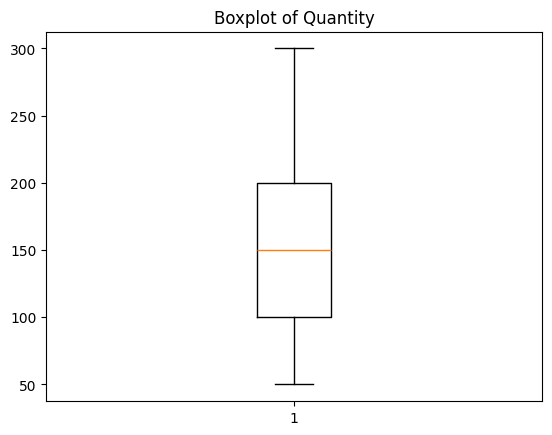

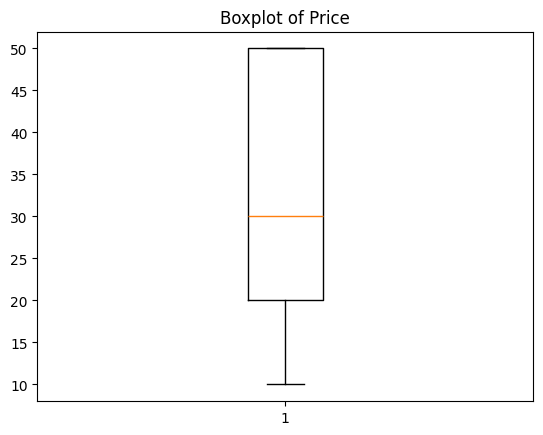

Quantity Outliers:
 Series([], Name: Quantity, dtype: float64)

Price Outliers:
 Series([], Name: Price, dtype: float64)

Original shape: (1000, 10)
No rows removed because values are valid inventory data


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. BOXPLOT VISUALIZATION
# ==============================

plt.figure()
plt.boxplot(df['Quantity'].dropna())
plt.title("Boxplot of Quantity")
plt.show()

plt.figure()
plt.boxplot(df['Price'].dropna())
plt.title("Boxplot of Price")
plt.show()


# ==============================
# 2. DETECT OUTLIERS (IQR METHOD)
# ==============================

def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = column[(column < lower) | (column > upper)]
    return outliers, lower, upper

# Detect
quantity_outliers, q_low, q_high = detect_outliers(df['Quantity'])
price_outliers, p_low, p_high = detect_outliers(df['Price'])

print("Quantity Outliers:\n", quantity_outliers)
print("\nPrice Outliers:\n", price_outliers)


# ==============================
# 3. DECISION (IMPORTANT)
# ==============================

print("\nOriginal shape:", df.shape)

# DO NOT REMOVE (important logic)
print("No rows removed because values are valid inventory data")

In [35]:
import pandas as pd

# Create supplier dataset manually
supplier_data = {
    "Supplier": ["Supplier A", "Supplier B", "Supplier C", "Supplier D"],
    "Supplier ID": [101, 102, 103, 104],
    "Country": ["India", "USA", "Germany", "China"]
}

supplier_df = pd.DataFrame(supplier_data)

# Display
supplier_df
# Merge with original dataset
merged_df = pd.merge(df, supplier_df, on="Supplier", how="inner")

# Display first 5 rows
merged_df.head()
print("Original shape:", df.shape)
print("After merge shape:", merged_df.shape)

Original shape: (1000, 10)
After merge shape: (1000, 12)


In [38]:
# Total Value = Quantity × Price
df['Total Value'] = df['Quantity'] * df['Price']

df[['Quantity', 'Price', 'Total Value']].head()

# Convert to datetime
df['Last Restocked'] = pd.to_datetime(df['Last Restocked'], dayfirst=True, errors='coerce')

# Extract Year and Month
df['Year'] = df['Last Restocked'].dt.year
df['Month'] = df['Last Restocked'].dt.month

df[['Last Restocked', 'Year', 'Month']].head()

# Function to categorize price
def price_category(price):
    if price < 20:
        return "Low"
    elif price < 40:
        return "Medium"
    else:
        return "High"

# Apply function
df['Price Range'] = df['Price'].apply(price_category)

df[['Price', 'Price Range']].head()

,Price,Price Range
0,9.99,Low
1,19.99,Low
2,19.99,Low
3,49.99,High
4,9.99,Low


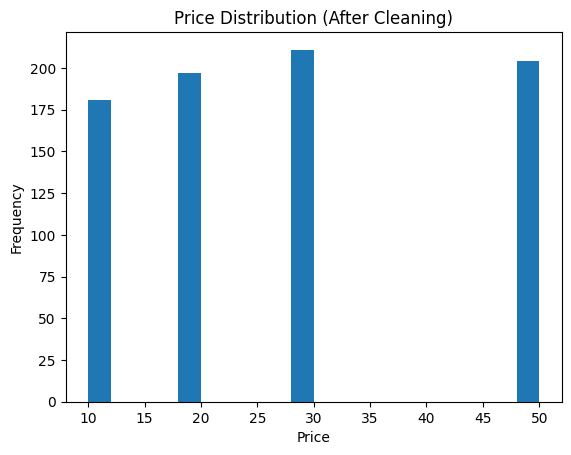

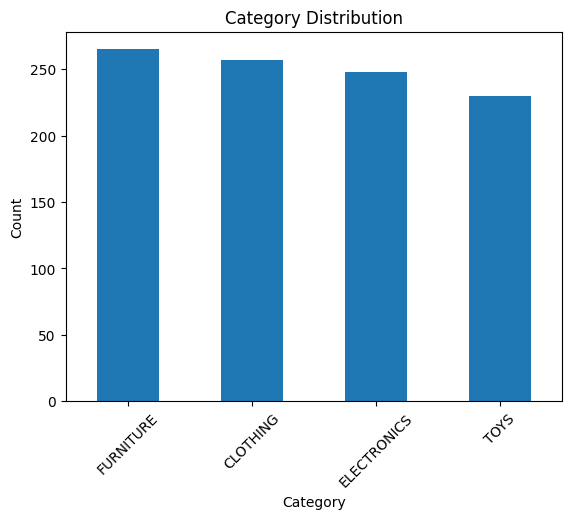

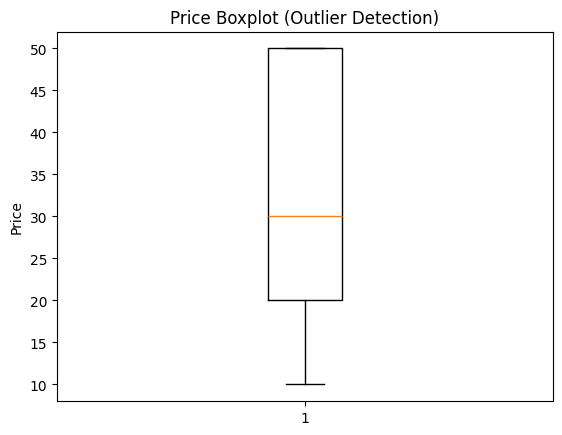

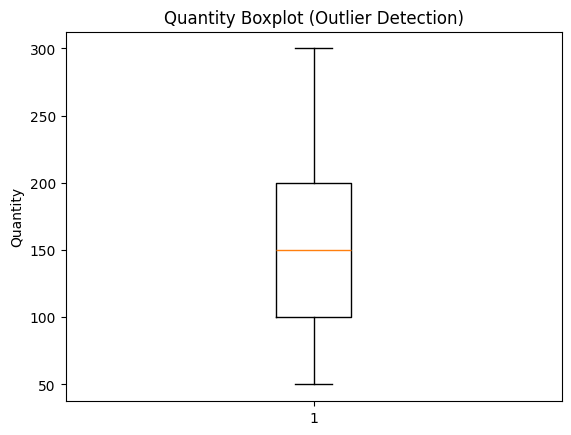

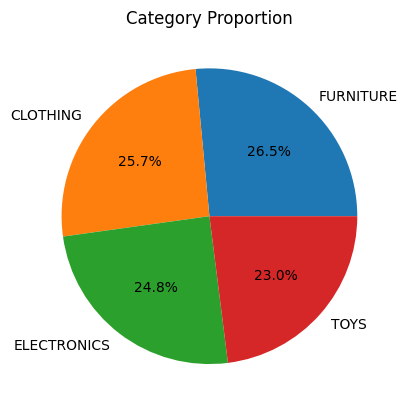

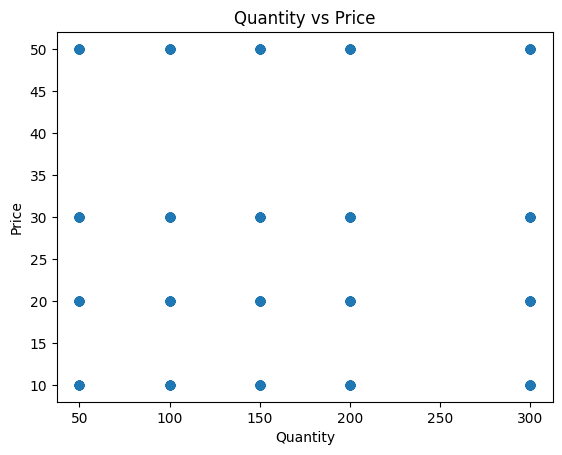

In [41]:
import matplotlib.pyplot as plt

# =========================
# HISTOGRAM OF PRICE
# =========================
plt.figure()
plt.hist(df['Price'].dropna(), bins=20)
plt.title('Price Distribution (After Cleaning)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


# =========================
# CATEGORY DISTRIBUTION (BAR)
# =========================
plt.figure()
df['Category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


# =========================
# BOXPLOT (EXTREME VALUES)
# =========================
plt.figure()
plt.boxplot(df['Price'].dropna())
plt.title('Price Boxplot (Outlier Detection)')
plt.ylabel('Price')
plt.show()


plt.figure()
plt.boxplot(df['Quantity'].dropna())
plt.title('Quantity Boxplot (Outlier Detection)')
plt.ylabel('Quantity')
plt.show()


# =========================
# PIE CHART (PROPORTION)
# =========================
plt.figure()
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Category Proportion')
plt.ylabel('')
plt.show()


# =========================
# SCATTER PLOT (RELATIONSHIP)
# =========================
plt.figure()
plt.scatter(df['Quantity'], df['Price'])
plt.title('Quantity vs Price')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.show()

In [53]:
# Fill numeric columns
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Price'] = df['Price'].fillna(df['Price'].mean())

# Fill categorical columns (UPDATED)
for col in df.select_dtypes(include=['object', 'string']):
    df[col] = df[col].fillna(df[col].mode()[0])
df_original = pd.read_csv("warehouse_messy_data.csv")
print("Before Cleaning Shape:", df_original.shape)
print("After Cleaning Shape:", df.shape)

print("\nMissing Values Before Cleaning:\n", df_original.isnull().sum())
print("\nMissing Values After Cleaning:\n", df.isnull().sum())

Before Cleaning Shape: (1000, 10)
After Cleaning Shape: (1000, 14)

Missing Values Before Cleaning:
 Product ID          0
Product Name        0
Category            0
Warehouse           0
Location            0
Quantity          158
Price             207
Supplier            0
Status              0
Last Restocked    200
dtype: int64

Missing Values After Cleaning:
 Product ID          0
Product Name        0
Category            0
Warehouse           0
Location            0
Quantity            0
Price               0
Supplier            0
Status              0
Last Restocked    200
Total Value       339
Year              200
Month             200
Price Range         0
dtype: int64


In [55]:
print("Insights After Cleaning:\n")

print("- Missing values handled using mean and mode")
print("- Quantity and Price converted to numeric")
print("- Invalid values like 'two hundred' converted to 200")
print("- Total Value = Quantity * Price created")
print("- Data is now clean and consistent")
print("- Visualizations are clearer")

Insights After Cleaning:

- Missing values handled using mean and mode
- Quantity and Price converted to numeric
- Invalid values like 'two hundred' converted to 200
- Total Value = Quantity * Price created
- Data is now clean and consistent
- Visualizations are clearer


In [51]:
import pandas as pd
import numpy as np
from word2number import w2n

# -------------------------------
# Convert Quantity (handle words like "two hundred")
# -------------------------------
def convert_quantity(x):
    try:
        return float(x)
    except:
        try:
            return float(w2n.word_to_num(str(x)))
        except:
            return np.nan

df['Quantity'] = df['Quantity'].apply(convert_quantity)

# Convert Price to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# -------------------------------
# Handle missing values
# -------------------------------
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Price'] = df['Price'].fillna(df['Price'].mean())

# Convert Quantity to integer (for proper output)
df['Quantity'] = df['Quantity'].astype(int)

# Convert date column
df['Last Restocked'] = pd.to_datetime(df['Last Restocked'], errors='coerce', dayfirst=True)

# -------------------------------
# 1. Top 5 Products by Quantity
# -------------------------------
top_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(5)

print("Top 5 Products by Quantity:\n")
print(top_products)

# -------------------------------
# 2. Most Expensive Category
# -------------------------------
expensive_category = df.groupby('Category')['Price'].mean().sort_values(ascending=False).head(1)

print("\nMost Expensive Category:\n")
print(expensive_category)

# -------------------------------
# 3. Frequently Restocked Products
# -------------------------------
restocked_products = df.groupby('Product Name')['Last Restocked'].count().sort_values(ascending=False).head(5)

print("\nFrequently Restocked Products:\n")
print(restocked_products)

Top 5 Products by Quantity:

Product Name
gadget y     29291
widget c     28725
gadget z     27836
widget a     27758
widget b     27497
Name: Quantity, dtype: int64

Most Expensive Category:

Category
ELECTRONICS    28.790035
Name: Price, dtype: float64

Frequently Restocked Products:

Product Name
widget c     143
widget a     141
gadget y     139
gadget z     135
widget b     134
Name: Last Restocked, dtype: int64


In [52]:
# Ensure Quantity is integer
df['Quantity'] = df['Quantity'].astype(int)

# Group by Category
category_group = df.groupby('Category').agg({
    'Quantity': 'sum',
    'Price': 'mean',
    'Total Value': 'sum'
})

print("Category-wise Analysis:\n")
print(category_group)

# Group by Supplier
supplier_group = df.groupby('Supplier').agg({
    'Quantity': 'sum',
    'Price': 'mean',
    'Total Value': 'sum'
})

print("\nSupplier-wise Analysis:\n")
print(supplier_group)

Category-wise Analysis:

             Quantity      Price  Total Value
Category                                     
CLOTHING        41416  28.003847     716252.5
ELECTRONICS     40086  28.790035     830214.0
FURNITURE       41179  28.173397     796211.5
TOYS            38657  27.317266     607261.0

Supplier-wise Analysis:

            Quantity      Price  Total Value
Supplier                                    
Supplier A     39230  28.383939     775725.0
Supplier B     45205  27.809243     764723.0
Supplier C     37185  27.769276     682758.0
Supplier D     39718  28.426371     726733.0
